(545, 13)
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5

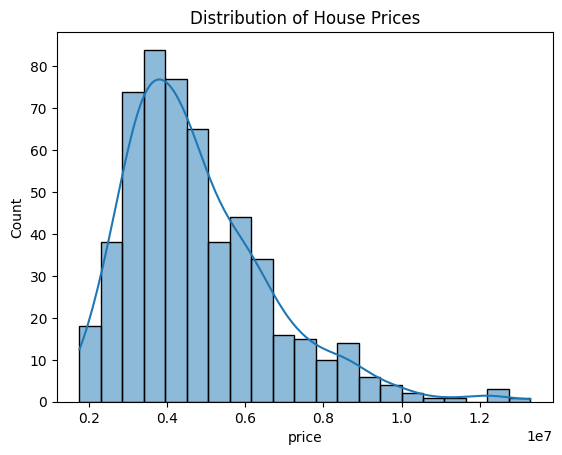

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Housing.csv")

# Inspect
print(df.shape)
print(df.info())
print(df.describe())

# Target distribution
sns.histplot(df['price'], kde=True)
plt.title("Distribution of House Prices")
plt.show()


In [ ]:
#Area: Strong predictor (larger area → higher price).
#Bedrooms, Bathrooms, Stories: Structural features that influence value.
#Parking: More parking → higher price.
#Location-related categorical features (Mainroad, Prefarea, Furnishing status): Encode demand and amenities.
#Age not present here but if included, older houses may depreciate.

In [4]:
# Fill missing numeric values with median
num_cols = ['area','bedrooms','bathrooms','stories','parking']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode
cat_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# One-Hot Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


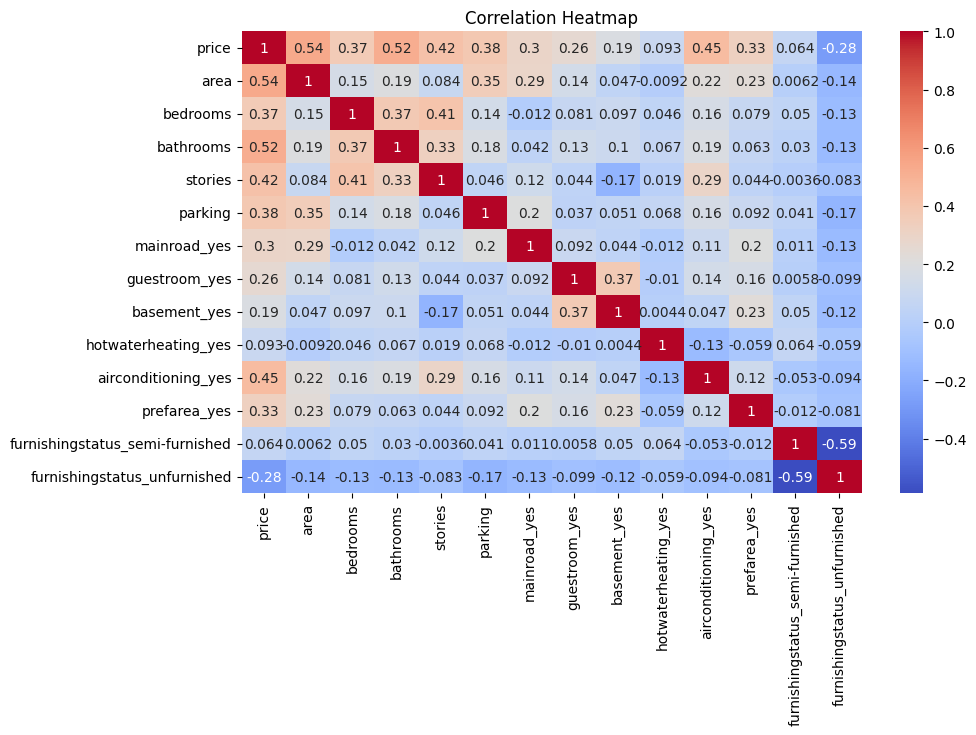

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)


In [9]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


MSE: 1754318687330.6643
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


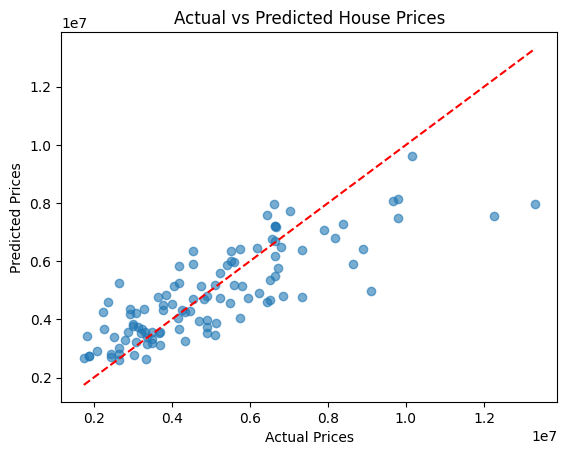

In [10]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


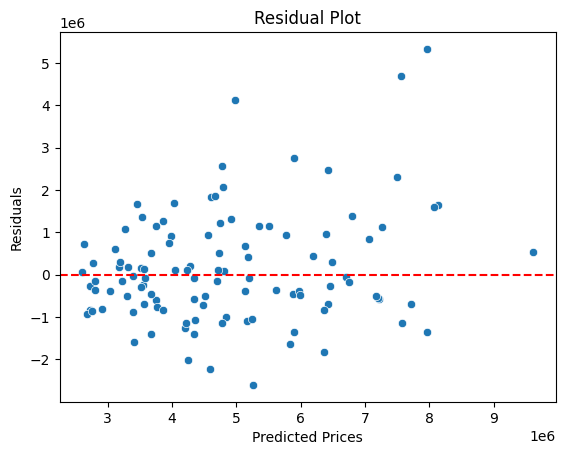

In [11]:
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [12]:
coeff_df = pd.DataFrame(lr.coef_, X.columns, columns=['Coefficient'])
print(coeff_df.sort_values(by='Coefficient', ascending=False))


                                  Coefficient
bathrooms                        1.094445e+06
airconditioning_yes              7.914267e+05
hotwaterheating_yes              6.846499e+05
prefarea_yes                     6.298906e+05
stories                          4.074766e+05
basement_yes                     3.902512e+05
mainroad_yes                     3.679199e+05
guestroom_yes                    2.316100e+05
parking                          2.248419e+05
bedrooms                         7.677870e+04
area                             2.359688e+02
furnishingstatus_semi-furnished -1.268818e+05
furnishingstatus_unfurnished    -4.136451e+05


In [ ]:
#Positive coefficients → increase price (e.g., area, premium furnishing).
#Negative coefficients → decrease price (e.g., absence of amenities).

In [13]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

print("Ridge R²:", ridge.score(X_test, y_test))
print("Lasso R²:", lasso.score(X_test, y_test))


Ridge R²: 0.6524978002155009
Lasso R²: 0.6529242591103016
